In [1]:
import os, sys, re, json, shutil, concurrent.futures
from math import floor
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
import scipy.ndimage as ndi
from tqdm import tqdm

sys.path.insert(0, '../Synthetic')
from index import SyntheticGenerator
from Utils.index import showTile, setFolder
from region_gen import strat_tile_worker

# BLOCO DE MARLIM

In [2]:
patch_metadata = 'files/patch_metadata.json'
marlim_patch   = '../Dataset/marlim/patch_1200'
predictions = [
    {'path': r'../Lucas/model_wu_u3d/marlim/patch_1200/masks',     'color': 'blue', 'label': 'modelo marlim 01'},
    {'path': r'../Lucas/model_mix_u3d_69/marlim/patch_1200/masks', 'color': 'red',  'label': 'modelo marlim 02'},
]

In [3]:
class MarlimBlock:
    """Monta o bloco de Marlim (img) e/ou máscaras (preds) a partir dos patches .dat e plota.
    preds: lista de caminhos ou dicts {'path','color','label'}. Eixos: (inline=d, z=h, xline=w)."""
    COLORS = [(1, 0, 0), (0, 1, 0), (0, 0.6, 1), (1, 1, 0), (1, 0, 1), (0, 1, 1)]

    def __init__(self, metadata_path, img=None, preds=None, patches_subdir='images'):
        self.meta = json.load(open(metadata_path))
        self.original_shape = tuple(self.meta['original_shape'])
        self.patch_size = self.meta['patch_size']
        self.overlap    = self.meta['overlap_voxels']
        self.do_overlap = self.meta['do_overlap']
        self.vmin, self.vmax = self.meta.get('vmin'), self.meta.get('vmax')
        self.patches_subdir = patches_subdir
        self.img_path = img
        self.paths, self.colors, self.labels = [], [], []
        for i, p in enumerate(preds or []):
            p = p if isinstance(p, dict) else {'path': p}
            self.paths.append(p['path'])
            self.colors.append(p.get('color'))
            self.labels.append(p.get('label', f'máscara {i}'))
        self._img_vol = None
        self._pred_vols = [None] * len(self.paths)

    def _resolve_dir(self, path):
        has = lambda d: os.path.isdir(d) and any(f.startswith('patch_d') and f.endswith('.dat') for f in os.listdir(d))
        if has(path):
            return path
        for sub in (self.patches_subdir, 'images', 'masks', 'predictions'):
            if has(os.path.join(path, sub)):
                return os.path.join(path, sub)
        raise FileNotFoundError(f'Nenhum patch_*.dat em {path}')

    def _reconstruct(self, path, desc='Montando'):
        ps, (fd, fh, fw) = self.patch_size, self.original_shape
        sc = ps - 2 * self.overlap if self.do_overlap else ps
        lim = [floor(n / sc) if self.do_overlap else n // ps for n in (fd, fh, fw)]
        s, e = self.overlap, ps - self.overlap
        dat_dir = self._resolve_dir(path)
        vol = np.zeros((fd, fh, fw), np.float32)
        for f in tqdm(sorted(os.listdir(dat_dir)), desc=desc):
            m = re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', f)
            if not m:
                continue
            d, h, w = [max(0, n - sc) if idx == L else idx * sc
                       for idx, L, n in zip(map(int, m.groups()), lim, (fd, fh, fw))]
            c = np.fromfile(os.path.join(dat_dir, f), np.float32).reshape((ps, ps, ps))
            c = c[s:e, s:e, s:e] if self.do_overlap else c
            cd, ch, cw = min(c.shape[0], fd - d), min(c.shape[1], fh - h), min(c.shape[2], fw - w)
            vol[d:d + cd, h:h + ch, w:w + cw] = c[:cd, :ch, :cw]
        return vol

    @property
    def img_volume(self):
        if self.img_path and self._img_vol is None:
            self._img_vol = self._reconstruct(self.img_path, 'bloco Marlim')
        return self._img_vol

    def pred_volume(self, i=0):
        if self._pred_vols[i] is None:
            self._pred_vols[i] = self._reconstruct(self.paths[i], f'máscara {i}')
        return self._pred_vols[i]

    @staticmethod
    def _slice(vol, axis, index):
        fd, fh, fw = vol.shape
        if axis == 'inline':
            i = fd // 2 if index is None else index; return vol[i], 'crossline', 'z', i
        if axis == 'crossline':
            i = fw // 2 if index is None else index; return vol[:, :, i].T, 'inline', 'z', i
        if axis in ('z', 'timeslice'):
            i = fh // 2 if index is None else index; return vol[:, i, :], 'crossline', 'inline', i
        raise ValueError("axis: 'inline', 'crossline' ou 'z'")

    def show(self, axis='inline', index=None, cmap='gray', figsize=(12, 6),
             threshold=0.5, alpha=0.6, show_masks=True, ax=None):
        """Fatia 2D: fundo = Marlim (ou preto se img=None) + máscaras coloridas com legenda."""
        if not self.img_path and not self.paths:
            raise ValueError('img e preds vazios.')
        ref = self.img_volume if self.img_path else self.pred_volume(0)
        bg, xl, yl, idx = self._slice(ref, axis, index)
        if self.img_path:
            vmin, vmax = self.vmin, self.vmax
        else:
            bg, vmin, vmax = np.zeros_like(bg), 0.0, 1.0
        created = ax is None
        if created:
            _, ax = plt.subplots(figsize=figsize)
        ax.imshow(bg, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
        handles = []
        if show_masks:
            for i in range(len(self.paths)):
                msl = self._slice(self.pred_volume(i), axis, index)[0]
                color = to_rgb(self.colors[i] or self.COLORS[i % len(self.COLORS)])
                rgba = np.zeros((*msl.shape, 4), np.float32)
                rgba[..., :3] = color
                rgba[..., 3] = np.clip(msl, 0, 1) * alpha if threshold is None else np.where(msl >= threshold, alpha, 0.0)
                ax.imshow(rgba, aspect='auto')
                handles.append(Patch(facecolor=color, alpha=alpha, label=self.labels[i]))
        title = ('Marlim' if self.img_path else 'Fundo preto') + (f' + {len(self.paths)} máscara(s)' if handles else '')
        ax.set_title(f'{title} — {axis} {idx} {ref.shape}')
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        if handles:
            ax.legend(handles=handles, loc='upper right', framealpha=0.9)
        if created:
            plt.tight_layout(); plt.show()
        return ax

bloco Marlim: 100%|██████████| 910/910 [00:03<00:00, 254.94it/s]


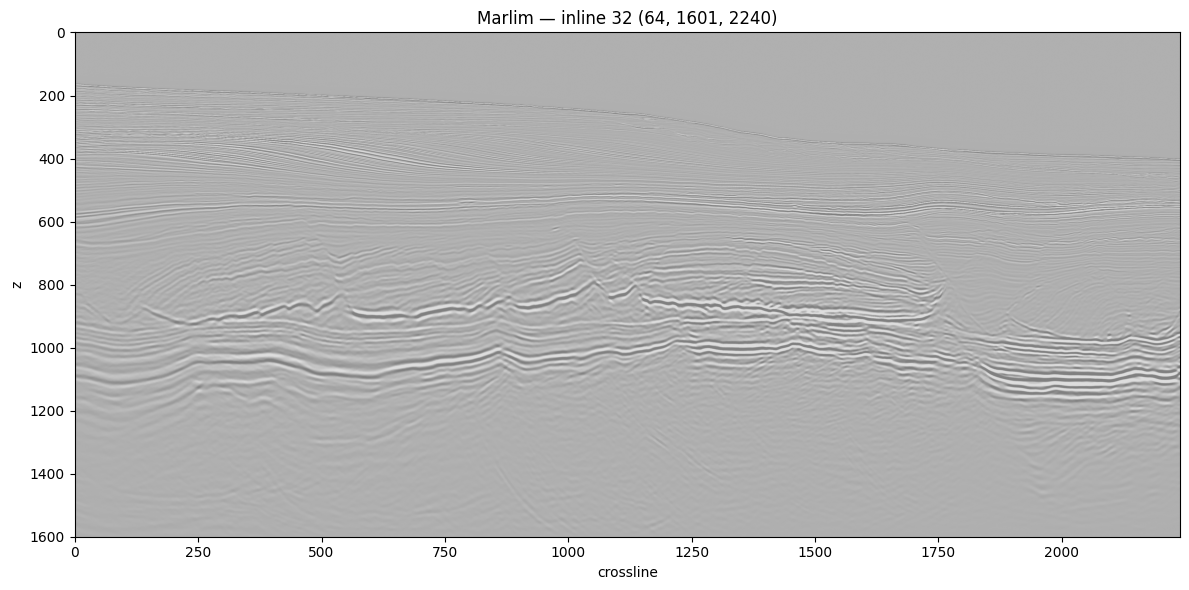

máscara 1: 100%|██████████| 910/910 [00:03<00:00, 263.74it/s]


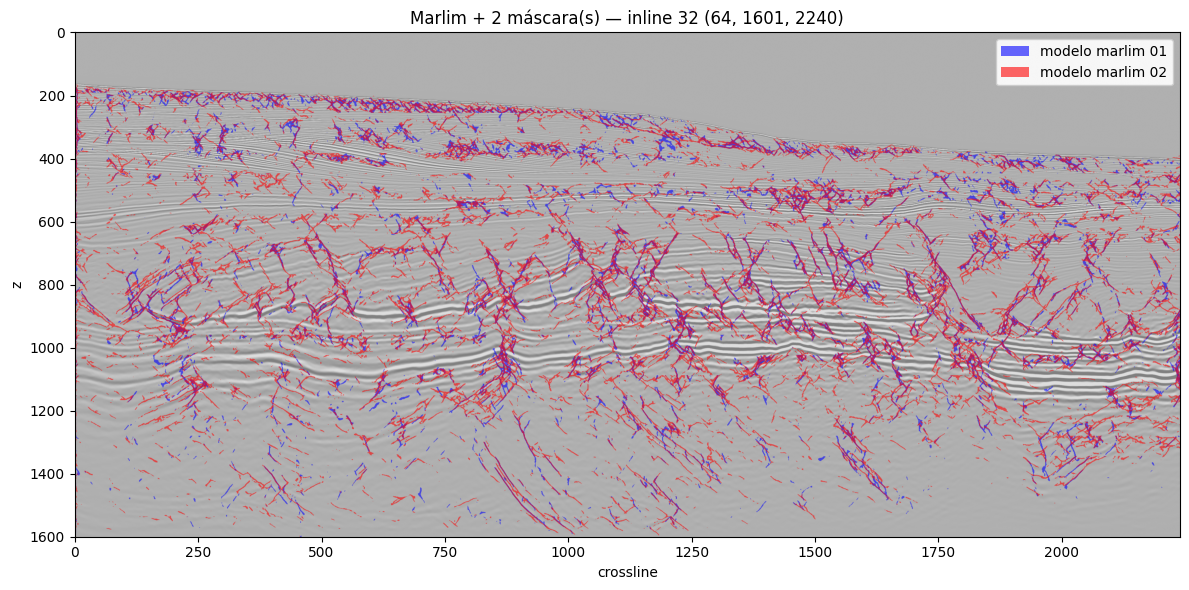

máscara 1: 100%|██████████| 910/910 [00:03<00:00, 298.44it/s]


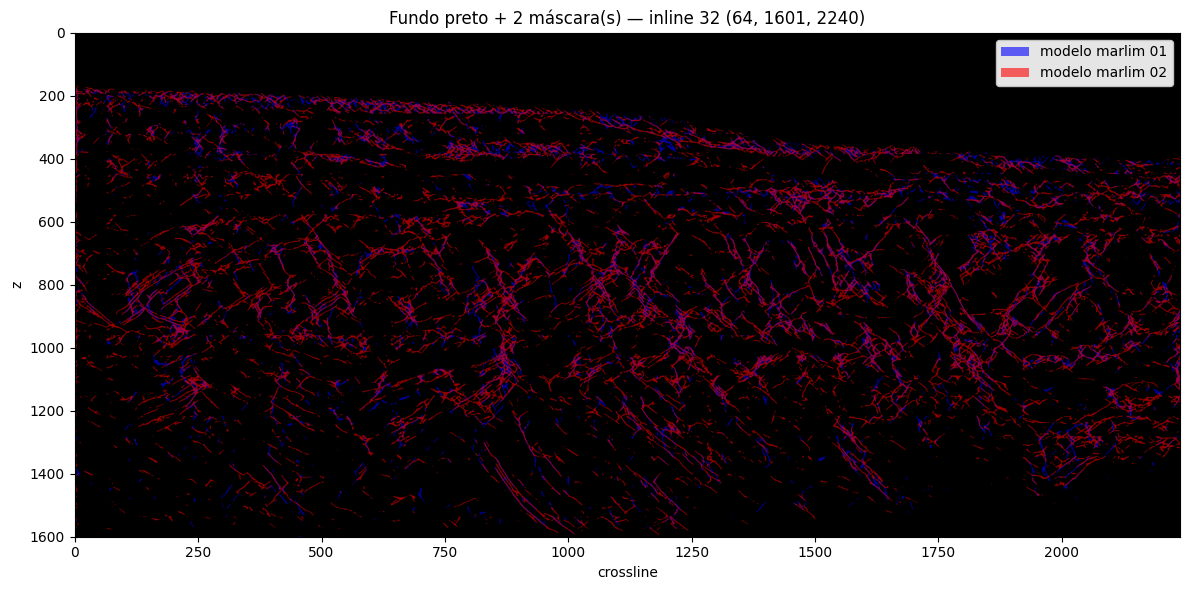

<Axes: title={'center': 'Fundo preto + 2 máscara(s) — inline 32 (64, 1601, 2240)'}, xlabel='crossline', ylabel='z'>

In [4]:
block = MarlimBlock(patch_metadata, img=marlim_patch, preds=predictions)
block.show(axis='inline', show_masks=False)
block.show(axis='inline', threshold=0.5, alpha=0.6)

mask_only = MarlimBlock(patch_metadata, img=None, preds=predictions)
mask_only.show(axis='inline', threshold=0.5)

# DATASET REGIONAL

In [5]:

BASE_OPT    = json.load(open('../Dataset/dataset_opt/synthetic.json'))   # config do MEIO
DATASET_DIR = '../Dataset/dataset_opt_calm/original'

# Regiões físicas do bloco (extensível: nova região = nova chave).
#   kind='strat'      -> SyntheticGenerator com BASE_OPT + overrides
#   kind='crosshatch' -> textura de fundo (ruído de migração), máscara vazia
#   z_real: banda z real p/ comparar | n: nº de tiles | color: cor da máscara
REGIONS = {
    'opt':  {'kind': 'strat', 'z_real': (600, 1200), 'n': 220, 'color': 'red',
             'desc': 'meio — dobrada e falhada', 'overrides': {}},
    'calm': {'kind': 'strat', 'z_real': (200, 600), 'n': 30, 'color': 'deepskyblue',
             'desc': 'topo — mar calminho (estratos planos, contínuos)',
             'overrides': {
                 'layerRange': [170, 260], 'layerThickness': [1, 2],
                 'foldCount': [2, 7], 'foldSigma': [45, 90], 'foldAmplitude': [-5, 5],
                 'foldBaseShift': [-0.4, 0.4], 'shearOffset': [-3, 3], 'shearGradient': [-0.05, 0.05],
                 'faultCount': [0, 3], 'faultThrow': [0, 8], 'faultDipAngle': [55, 85],
                 'waveletFreq': [95, 120], 'noiseLevel': [0.01, 0.12]}},
    'deep': {'kind': 'crosshatch', 'z_real': (1200, 1600), 'n': 30, 'color': 'lime',
             'desc': 'fundo — transparente (crosshatch de ruído de migração)',
             'texture': {'angle': 30, 'wavelet_f': 34, 'streak_w': 0.5, 'blob_w': 1.0, 'xcorr': 2.0}},
}

In [6]:
class RegionSynth:
    """Gera, compara e verifica tiles sintéticos por região (dict REGIONS).
    'strat' usa SyntheticGenerator(BASE_OPT+overrides); 'crosshatch' usa textura de fundo."""

    def __init__(self, regions, base_opt, dataset_dir):
        self.regions, self.base_opt, self.dir = regions, base_opt, dataset_dir
        self.img_dir = os.path.join(dataset_dir, 'images')
        self.msk_dir = os.path.join(dataset_dir, 'masks')

    def config(self, r):
        return {**self.base_opt, **self.regions[r].get('overrides', {})}

    @staticmethod
    def _z(a):
        return (a - a.mean()) / (a.std() + 1e-8)

    # ---- textura de fundo (crosshatch de ruído de migração; máscara vazia) ----
    @classmethod
    def _dir_noise(cls, shape, ang, elong, thick, xcorr, rng):
        n = rng.standard_normal(shape).astype(np.float32)
        n = ndi.rotate(n, ang, axes=(1, 2), reshape=False, order=1, mode='reflect')
        n = ndi.gaussian_filter(n, (xcorr, elong, thick))
        return ndi.rotate(n, -ang, axes=(1, 2), reshape=False, order=1, mode='reflect')

    @classmethod
    def crosshatch(cls, seed=None, shape=(128, 128, 128),
                   angle=30, wavelet_f=34, streak_w=0.5, blob_w=1.0, xcorr=2.0):
        rng = np.random.default_rng(seed)
        a = angle + rng.uniform(-7, 7)
        streak = cls._z(cls._dir_noise(shape, a, 9, 2.6, xcorr, rng) +
                        cls._dir_noise(shape, -a, 9, 2.6, xcorr, rng))
        blob = cls._z(ndi.gaussian_filter(rng.standard_normal(shape).astype(np.float32), (xcorr, 4, 4)))
        t = blob_w * blob + streak_w * streak
        tt = np.arange(-0.08, 0.08, 0.004)
        w = (1 - 2 * (np.pi * wavelet_f * tt) ** 2) * np.exp(-((np.pi * wavelet_f * tt) ** 2))
        t = ndi.gaussian_filter(ndi.convolve1d(t, w, axis=1), (0.5, 0.8, 0.8))
        return cls._z(t).astype(np.float32), np.zeros(shape, np.uint8)

    def tile(self, region, seed=None):
        """1 tile (img, mask) no formato salvo (x, depth, y), despachando por 'kind'."""
        info = self.regions[region]
        if info['kind'] == 'crosshatch':
            return self.crosshatch(seed=seed, **info['texture'])
        if seed is not None:
            np.random.seed(seed)
        g = SyntheticGenerator(); g.set(self.config(region))
        im, mk = g.get()
        return np.transpose(im, (0, 2, 1)), np.transpose(mk, (0, 2, 1))

    # ---- comparação real × sintético ----
    def _dataset_sections(self, region, k):
        man = os.path.join(self.dir, 'regions_manifest.json')
        if not os.path.exists(man):
            return None
        idxs = [it['index'] for it in json.load(open(man))['items'] if it['region'] == region][:k]
        out  = []
        for i in idxs:
            fi = os.path.join(self.img_dir, f'img_{i:04d}.npy')
            fm = os.path.join(self.msk_dir, f'img_{i:04d}.npy')
            if not (os.path.exists(fi) and os.path.exists(fm)):
                return None
            im, mk = np.load(fi), np.load(fm); c = im.shape[0] // 2
            out.append((im[c], mk[c]))
        return out or None

    def compare(self, region, vol, k=3, seed=0):
        """Real (banda z) × sintético, z-score por painel + rugosidade vertical."""
        info = self.regions[region]
        rng = np.random.default_rng(seed); il = vol.shape[0] // 2; z0, z1 = info['z_real']
        reals = []
        for _ in range(k):
            z = rng.integers(z0, z1 - 128); x = rng.integers(0, vol.shape[2] - 128)
            reals.append(vol[il, z:z + 128, x:x + 128])
        tiles = self._dataset_sections(region, k)
        if tiles is None:
            tiles = [(lambda im, mk: (im[im.shape[0] // 2], mk[im.shape[0] // 2]))(*self.tile(region, seed + j))
                     for j in range(k)]
        fig, ax = plt.subplots(k, 2, figsize=(9, 4 * k)); ax = np.atleast_2d(ax)
        for j in range(k):
            ax[j, 0].imshow(self._z(reals[j]), cmap='gray', aspect='auto', vmin=-2.5, vmax=2.5)
            ax[j, 0].set_title(f'REAL {region} z{info["z_real"]}'); ax[j, 0].set_ylabel('z')
            s, m = tiles[j]
            ax[j, 1].imshow(self._z(s), cmap='gray', aspect='auto', vmin=-2.5, vmax=2.5)
            if m.any():
                ax[j, 1].imshow(np.ma.masked_where(m == 0, m), cmap='autumn', alpha=0.5, aspect='auto')
            ax[j, 1].set_title(f'SYNTH {region} (mask={m.mean():.3f})')
        fig.suptitle(f'[{region}] {info["desc"]}', y=1.005); plt.tight_layout(); plt.show()
        rough = lambda a: float(np.abs(np.diff(self._z(a), 0)).mean())
        print(f'[{region}] rugosidade_z  real={np.mean([rough(r) for r in reals]):.3f}  '
              f'synth={np.mean([rough(t[0]) for t in tiles]):.3f}')

    def compare_all(self, vol, k=3):
        for r in self.regions:
            self.compare(r, vol, k)

    # ---- geração segura (temp + troca atômica) e idempotente ----
    def complete(self):
        man = os.path.join(self.dir, 'regions_manifest.json')
        if not os.path.exists(man):
            return False
        items = json.load(open(man))['items']
        return (len(items) == sum(r['n'] for r in self.regions.values()) and
                all(os.path.exists(os.path.join(self.img_dir, f"img_{it['index']:04d}.npy")) for it in items))

    def generate(self, force=False, n_jobs=None):
        if self.complete() and not force:
            print('dataset já completo — force=True para regerar.'); return
        ti, tm = self.img_dir + '_tmp', self.msk_dir + '_tmp'
        setFolder(ti); setFolder(tm)
        base = np.random.randint(0, 1_000_000)
        strat, cross, manifest, idx = [], [], [], 0
        for name, info in self.regions.items():
            payload = {'kind': 'crosshatch', **info['texture']} if info['kind'] == 'crosshatch' else self.config(name)
            json.dump(payload, open(os.path.join(self.dir, f'{name}.json'), 'w'), indent=2)
            for _ in range(info['n']):
                if info['kind'] == 'crosshatch':
                    cross.append((idx, name, base + idx))
                else:
                    strat.append((idx, self.config(name), base + idx, ti, tm))
                manifest.append({'index': idx, 'region': name}); idx += 1
        with concurrent.futures.ProcessPoolExecutor(max_workers=n_jobs or os.cpu_count()) as ex:
            list(tqdm(ex.map(strat_tile_worker, strat), total=len(strat), desc='strat'))
        for i, name, seed in tqdm(cross, desc='crosshatch'):
            im, mk = self.tile(name, seed=seed)
            np.save(os.path.join(ti, f'img_{i:04d}.npy'), im); np.save(os.path.join(tm, f'img_{i:04d}.npy'), mk)
        shutil.rmtree(self.img_dir, ignore_errors=True); shutil.rmtree(self.msk_dir, ignore_errors=True)
        os.rename(ti, self.img_dir); os.rename(tm, self.msk_dir)
        json.dump({'base_seed': int(base), 'items': manifest},
                  open(os.path.join(self.dir, 'regions_manifest.json'), 'w'), indent=2)
        print(f'OK: {len(manifest)} tiles em {self.dir}')

    # ---- verificação do dataset ----
    def verify(self, show=True):
        items = json.load(open(os.path.join(self.dir, 'regions_manifest.json')))['items']
        by = {}
        for it in items:
            by.setdefault(it['region'], []).append(it['index'])
        for reg, idxs in by.items():
            fr = [float(np.load(os.path.join(self.msk_dir, f'img_{i:04d}.npy')).mean()) for i in idxs]
            print(f'{reg:5s} n={len(idxs):3d}  mask_frac={np.mean(fr):.4f}  sem_falha={sum(f == 0 for f in fr)}')
        if show:
            for reg, idxs in by.items():
                i = idxs[0]
                print(f'\n=== {reg} img_{i:04d} — {self.regions[reg]["desc"]} ===')
                showTile(np.load(os.path.join(self.img_dir, f'img_{i:04d}.npy')), np.load(os.path.join(self.msk_dir, f'img_{i:04d}.npy')))

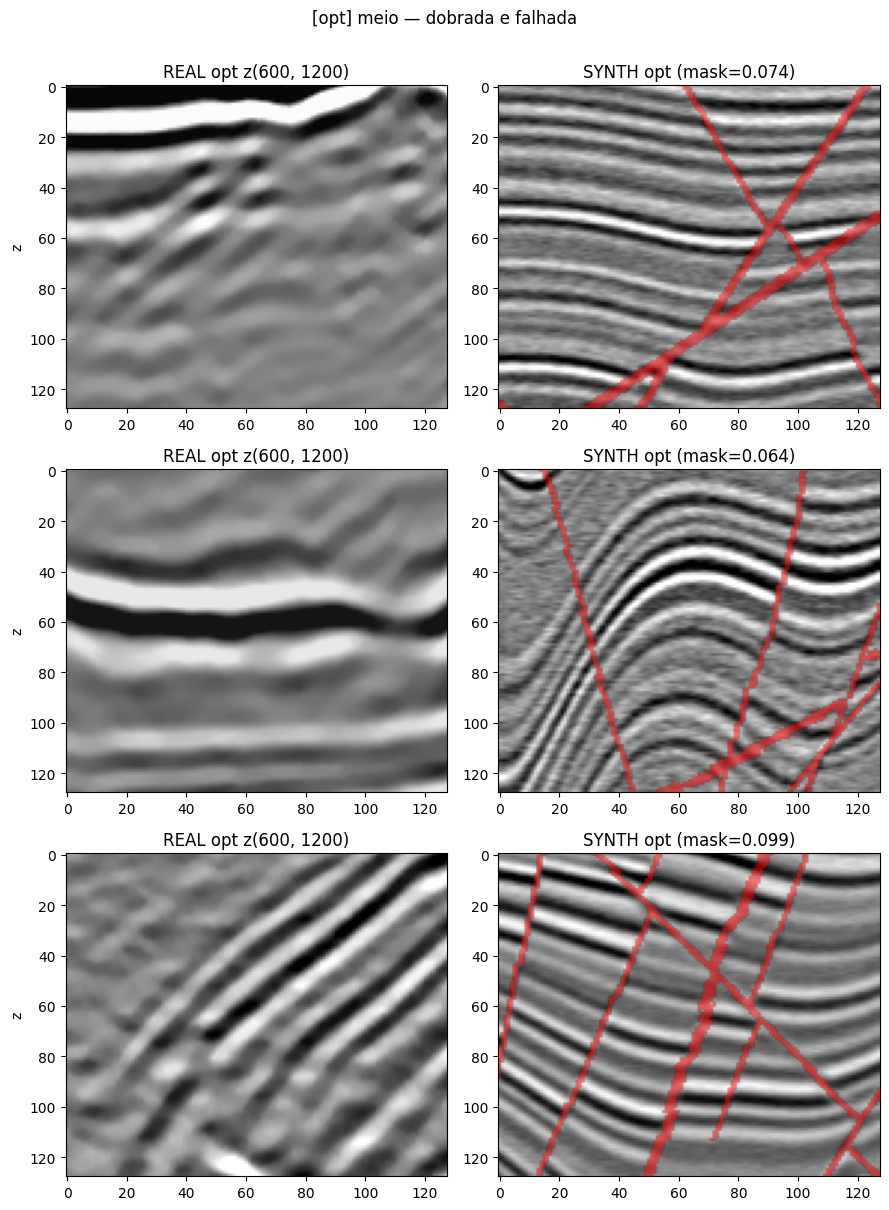

[opt] rugosidade_z  real=0.744  synth=0.787


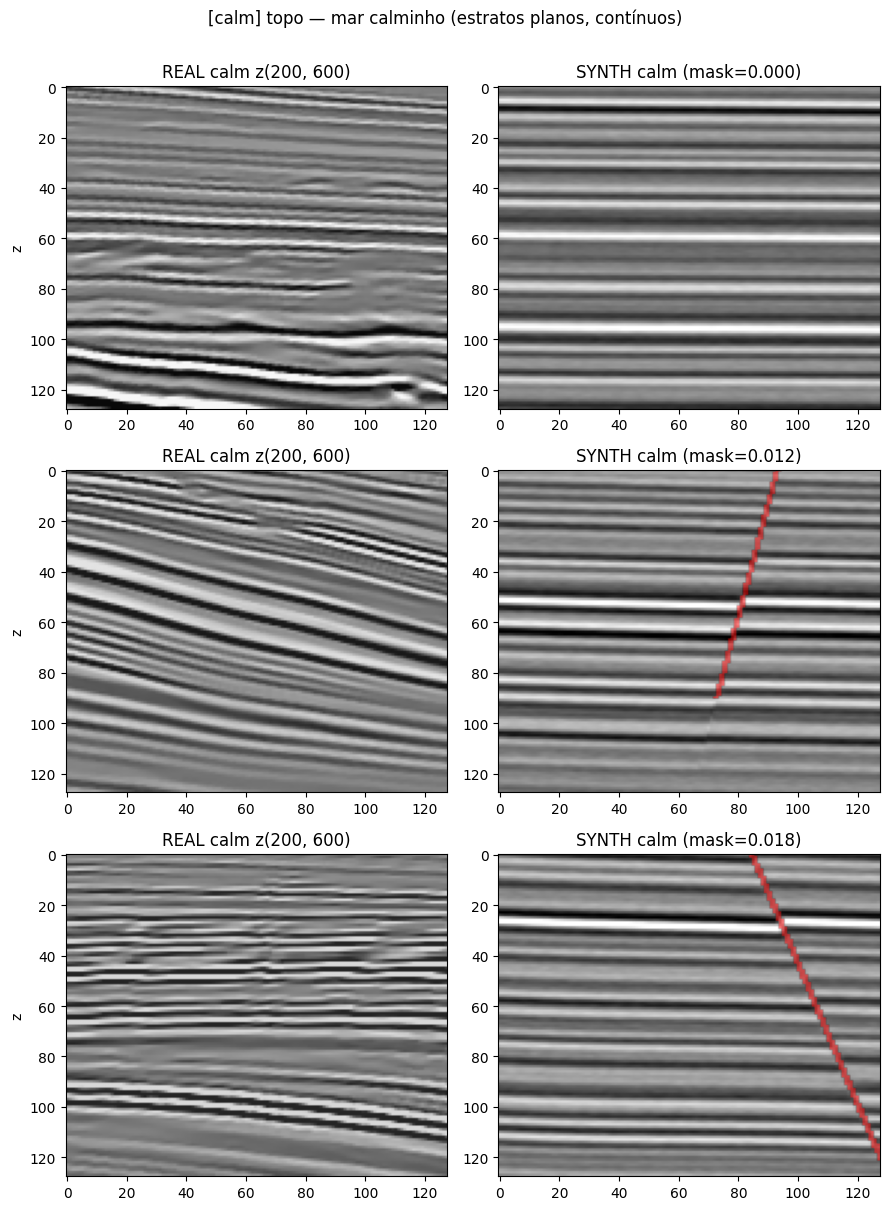

[calm] rugosidade_z  real=0.790  synth=0.800


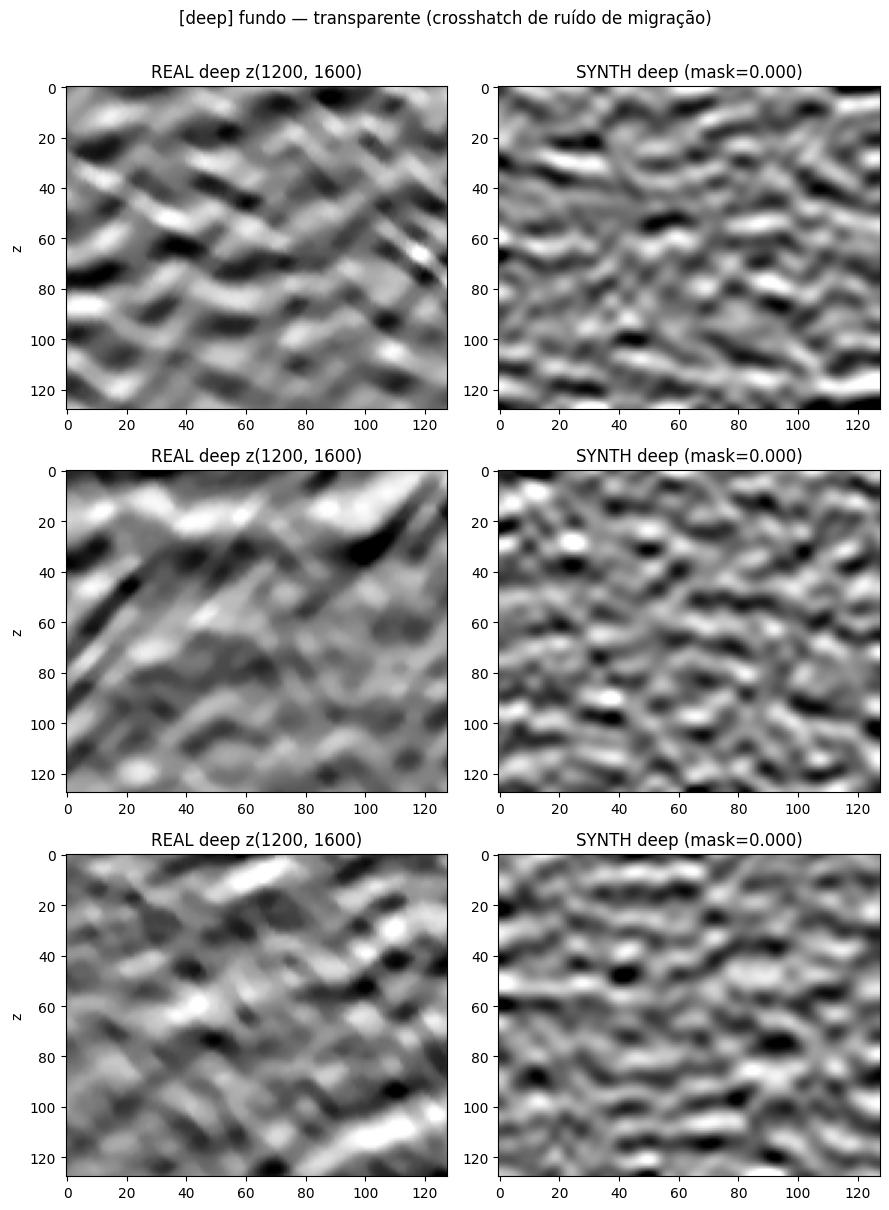

[deep] rugosidade_z  real=0.794  synth=0.791


In [7]:
study = RegionSynth(REGIONS, BASE_OPT, DATASET_DIR)
study.compare_all(block.img_volume)

crosshatch: 100%|██████████| 30/30 [00:19<00:00,  1.55it/s]


OK: 280 tiles em ../Dataset/dataset_opt_calm/original
opt   n=220  mask_frac=0.0726  sem_falha=0
calm  n= 30  mask_frac=0.0089  sem_falha=10
deep  n= 30  mask_frac=0.0000  sem_falha=30

=== opt img_0000 — meio — dobrada e falhada ===


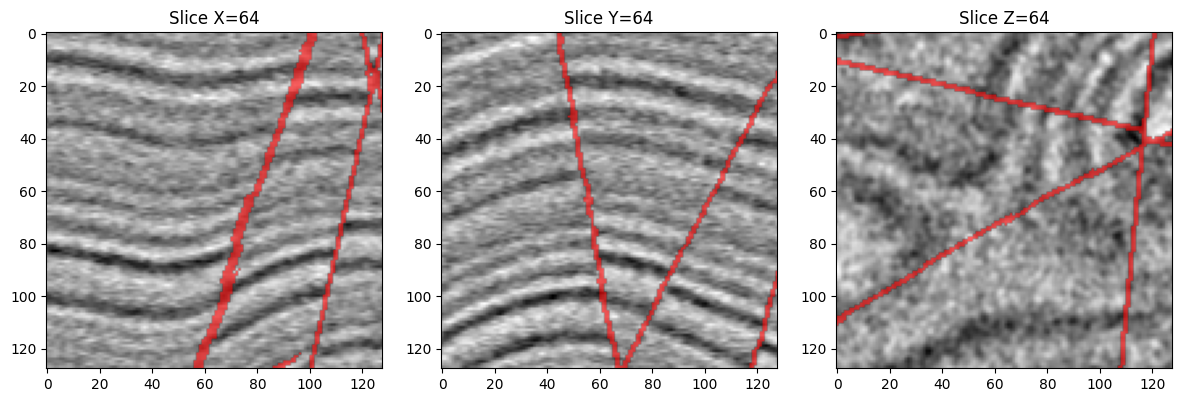


=== calm img_0220 — topo — mar calminho (estratos planos, contínuos) ===


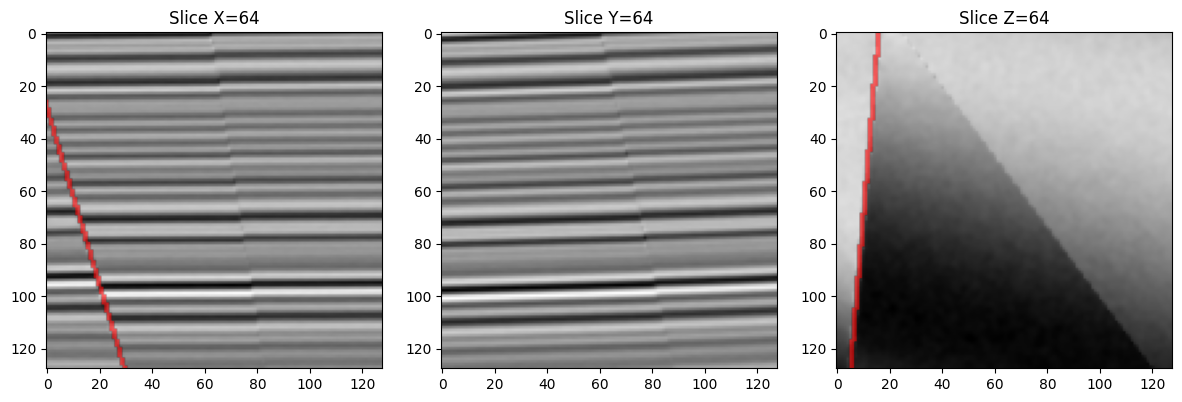


=== deep img_0250 — fundo — transparente (crosshatch de ruído de migração) ===


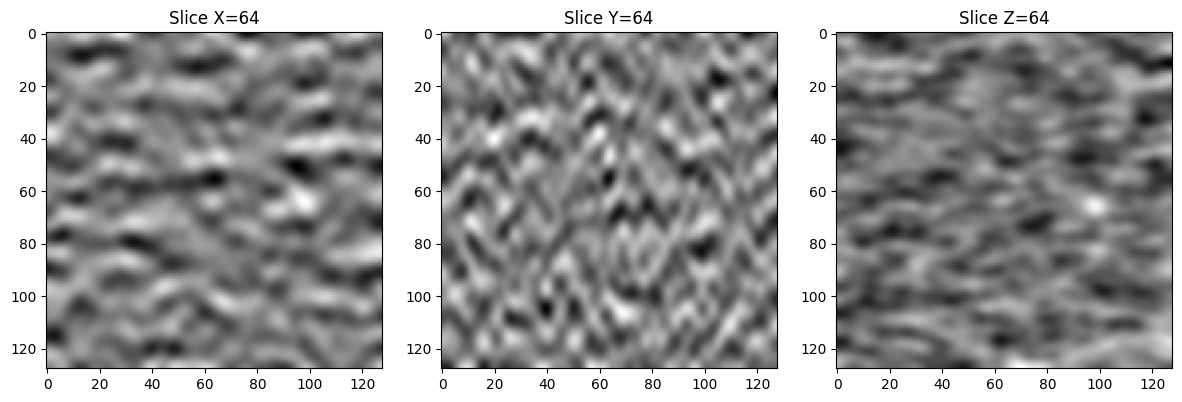

In [8]:
study.generate()
study.verify()